Import packages and construct list of DEMs (stored in dems var).

In [9]:
from pathlib import Path #to access data by path
import topotoolbox as ttb #to handle data
import matplotlib.pyplot as plt #for plotting
import numpy as np #for handling large amounts of data (arrays not lists)
from datetime import datetime as dt #to process the date of dems


rasterFolder = Path('Snow Depth Rasters')
dems = [] #snow depth dems

# #loop through each file in snow rasters folder
for file in Path("Snow Depth Rasters").iterdir():
    #ensure file is .tif
    if file.is_file() and file.suffix.lower() == '.tif':
        dem = ttb.read_tif(file)
        dems.append(dem)

bsDem = ttb.read_tif(r"NonDepthData\MTBS_Resampled_1m.tif") #raster containing burn severity data
sfDem = ttb.read_tif(r"NonDepthData\DEM_063025_SnowFree.tif") #raster of snow free slope

Create a box plot based on parameters: data (array of numerical values), title (plot title), dataLabel (label describing the numerical data), and criteriaLabel (special criteria this dataset meets).

In [10]:
def makeBoxPlot(data : np.array, title : str, dataLabel : str, criteriaLabel : str):
    if len(data) <= 1: return

    #Setup plot
    plt.figure(figsize=(8, 4))
    plt.boxplot(data)

    #Setup labels
    plt.title(title)
    plt.xlabel(criteriaLabel)
    plt.ylabel(dataLabel)

    #Show plot
    plt.show()

Function that takes the raw name of a dem and processes it into a readable format.

In [11]:
def processDemName(rawName : str):
    rawDate = rawName.split("_")[1] #get date string from name (will take whatever string comes after the first underscore)
    date = dt.strptime(rawDate, "%m%d%y").date() #get date object from string
    name = "Lidar drone data - " + date.strftime("%m/%d/%y") #convert date object back to string
    return name

-import SD rasters, import DEM, LAI, burn severity

-use topotoolbox to generate slope, aspect, northness, eastness rasters

-create scatter plots of snow depth on each date vs independent variables

Process snow depth data and make box plots.

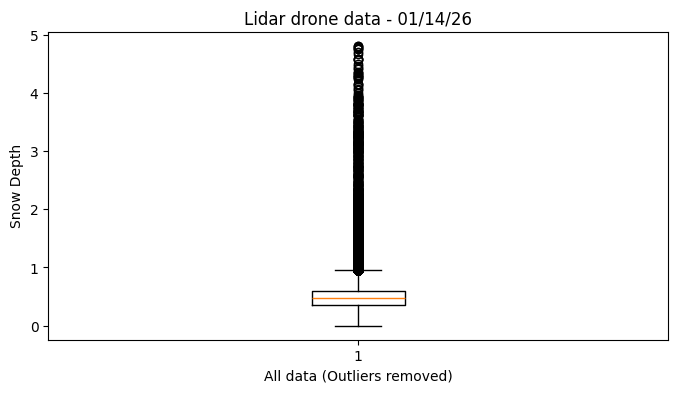

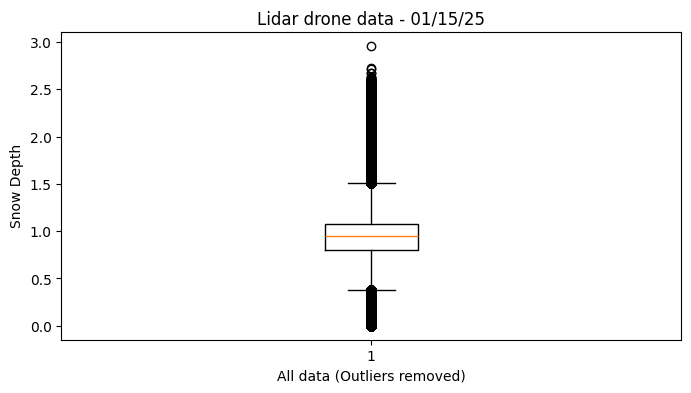

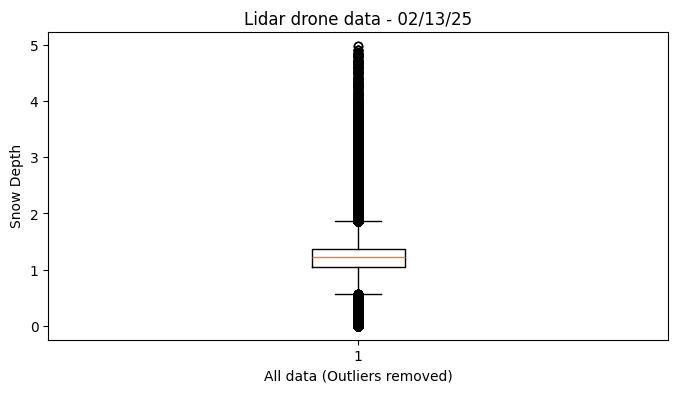

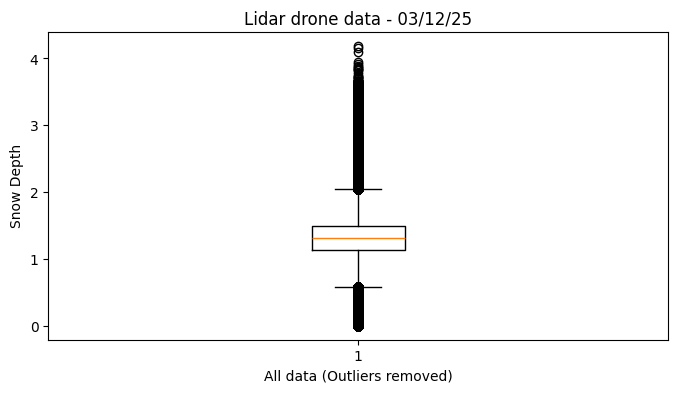

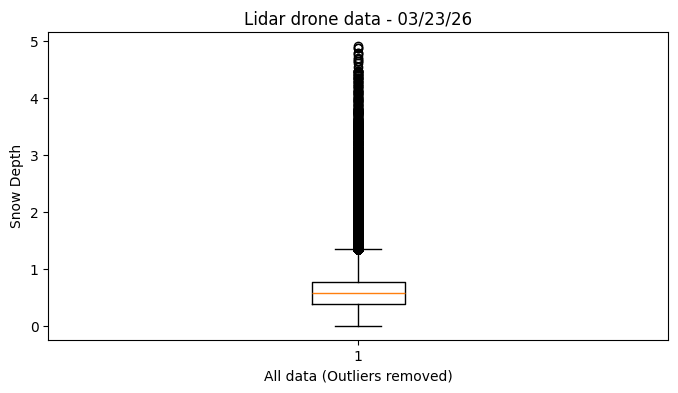

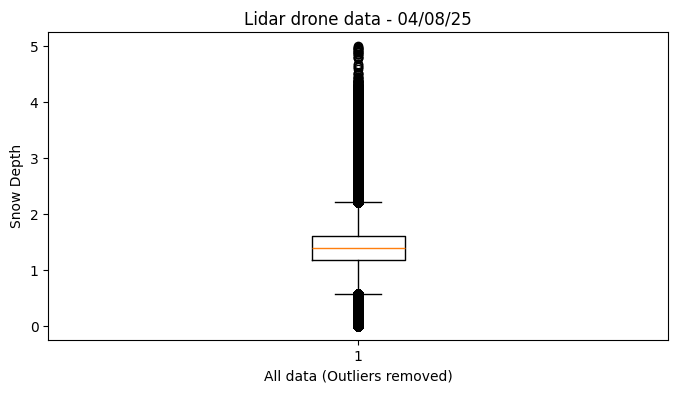

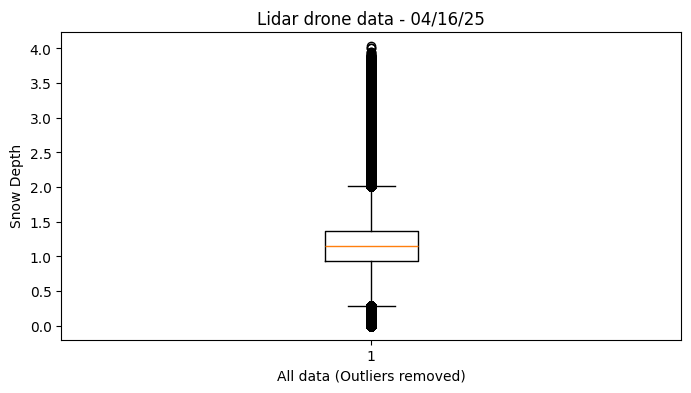

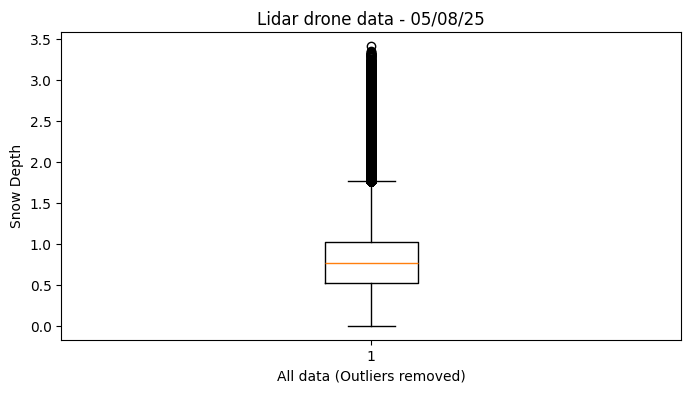

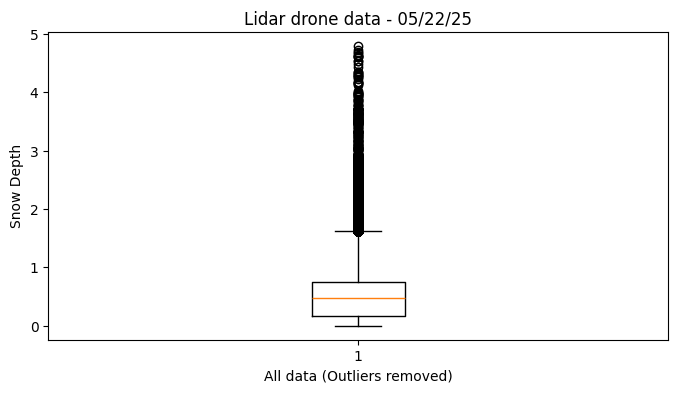

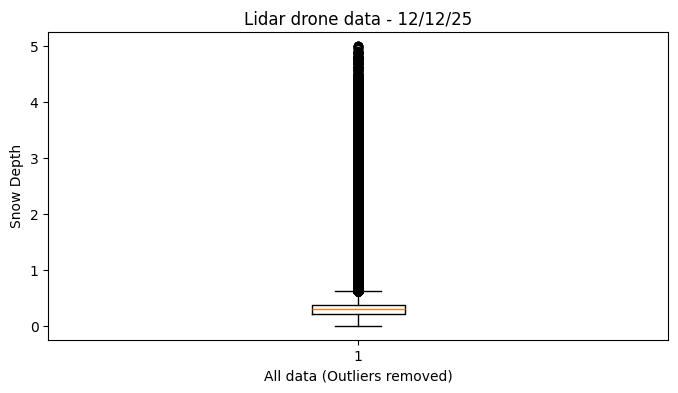

In [12]:
totalList = []

for dem in dems:
    #get size of data (stored in vars rows & cols) TODO: USE OR DELETE
    rows, cols = dem.shape 
    
    #store all depths in array
    depths = dem.z.ravel()

    #filter out any points less than -0.1 or greater than 5, if a remaining value is less than 0 it will be set to zero
    depths = depths[depths > -0.1] 
    depths = depths[depths < 5.0]
    depths[depths < 0] = 0 

    #make box plot of depths
    makeBoxPlot(depths, processDemName(dem.name), "Snow Depth", "All data (Outliers removed)")